# 🛍️ Système de Recommandation H&M avec LightFM

## Objectif du Projet
Développer un système de recommandation complet pour le commerce électronique de mode en utilisant le dataset H&M et la bibliothèque LightFM. Ce projet implémente un pipeline end-to-end allant de l'exploration des données jusqu'au déploiement d'un modèle hybride combinant filtrage collaboratif et métadonnées d'articles.

## Approche Technique
- **Filtrage Collaboratif** : Analyse des interactions utilisateur-article
- **Modèle Hybride** : Intégration des métadonnées (catégories, âge, couleur)
- **Optimisation** : Recherche en grille des hyperparamètres
- **Évaluation** : Métriques AUC, Precision@K, Recall@K

## Consignes du Projet
[Consignes détaillées](https://docs.google.com/document/d/16ZCFuI9-aKwK2FuTMmAgbsrI7gbMFuswlYlmFF2MnkU/edit?usp=drive_link)


## 📋 Table des Matières

### **1. Configuration de l'Environnement**
- Installation des dépendances et imports
- Chargement des données H&M

### **2. Fonctions Utilitaires**
- Fonctions réutilisables pour le pipeline

### **3. Exploration des Données**
- Analyse de la sparsité et des distributions
- Identification des patterns utilisateur-article

### **4. Stratégie d'Échantillonnage**
- Création d'échantillons représentatifs
- Filtrage des utilisateurs et articles actifs

### **5. Pipeline Principal**
- Prétraitement et construction des matrices
- Entraînement des modèles CF et hybrides
- Optimisation des hyperparamètres

### **6. Analyse Comparative**
- Comparaison des performances
- Visualisations des résultats

### **7. Déploiement**
- Sauvegarde du modèle
- Guide de déploiement MVP

---



## Informations du Projet

| **Attribut** | **Détails** |
|--------------|-------------|
| **Titre** | Pipeline de Recommandation de Mode H&M |
| **Dépôt GitHub** | [github.com/realnribal/hm-fashion-recommendation-pipeline](https://github.com/realnribal/hm-fashion-recommendation-pipeline) |
| **Framework** | [LightFM](https://making.lyst.com/lightfm/docs/home.html) |
| **Dataset** | [H&M Fashion Data](https://drive.google.com/drive/folders/1QCnycWNFvy0iz3JXKhW--YlLNtwiLPSn?usp=drive_link) |

## Auteurs

| **Auteur** | **Email** |
|-----------|-----------|
| Henri BALAMOU | henri.balamou@dauphine.eu |
| Rachna HEAN | rachna.hean@dauphine.eu |




## Guide d'Utilisation

### Instructions Rapides
1. **Ouvrir** : [Google Colab](https://colab.research.google.com) → Importer ce fichier `.ipynb`
2. **Préparer les données** : Placer `transactions_train.csv`, `articles.csv`, `customers.csv` dans Google Drive
3. **Exécuter** : "Exécuter tout" ou cellule par cellule (⌘/Ctrl + Entrée)

### Prérequis
- Compte Google (pour Colab et Drive)
- Datasets H&M : [Télécharger ici](https://drive.google.com/drive/folders/1QCnycWNFvy0iz3JXKhW--YlLNtwiLPSn?usp=drive_link)

### Personnalisation
- **Taille d'échantillon** : Modifier `user_sample_sizes = [1000, 10000, 50000]` (cellule 16)
- **Hyperparamètres** : Ajuster `components_list` et `learning_rates` (cellule 9)


## Configuration de l'Environnement

Cette section configure l'environnement de travail pour notre projet de système de recommandation.

**Objectif :** Préparer l'environnement Python avec toutes les dépendances nécessaires et charger les données H&M.

**Étapes :**
1. Monter Google Drive pour accéder aux datasets
2. Installer les bibliothèques nécessaires (LightFM, pandas, etc.)
3. Importer les modules Python requis
4. Charger les données depuis les fichiers CSV

**Note :** Assurez-vous d'avoir placé les fichiers `transactions_train.csv`, `articles.csv`, et `customers.csv` dans votre Google Drive.

In [6]:
# ============================================================================
# CONFIGURATION DE L'ENVIRONNEMENT
# ============================================================================

# Étape 1 : Monter Google Drive et configurer le chemin des données
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_path = '/content/drive/MyDrive/PSL/00-RecommanderSystem/h2m-recsys/data/'
    print("✅ Google Drive monté avec succès")
except ImportError:
    print("⚠️ Google Colab non détecté. Utilisation du chemin local.")
    data_path = './data/'  # Adapter selon votre environnement local

⚠️ Google Colab non détecté. Utilisation du chemin local.


In [7]:
# Étape 2 : Installer les dépendances nécessaires
import subprocess
import sys

# Liste des packages requis
packages = [
    'git+https://github.com/daviddavo/lightfm',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'scipy'
]

# Installation des packages
for package in packages:
    try:
        if package.startswith('git+'):
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        else:
            __import__(package)
    except:
        if package.startswith('git+'):
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✅ Toutes les dépendances sont installées")

✅ Toutes les dépendances sont installées


In [8]:
# Étape 3 : Importer toutes les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
from lightfm.data import Dataset
from sklearn.model_selection import train_test_split
import warnings
import time
import psutil
import pickle
import os

# Configuration des paramètres d'affichage
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Tous les imports sont complètement réalisés")

✅ Tous les imports sont complètement réalisés


In [9]:
num_threads=psutil.cpu_count()
num_threads

14

In [10]:
# Étape 4 : Charger les données H&M
print("=" * 70)
print("CHARGEMENT DES DONNÉES H&M")
print("=" * 70)

# Configuration des colonnes et types pour optimiser la mémoire
transactions_cols = ['t_dat', 'customer_id', 'article_id']
articles_cols = ['article_id', 'prod_name', 'product_type_name', 'product_group_name',
                 'department_name', 'colour_group_name']
customers_cols = ['customer_id', 'age']

# Types de données optimisés
transactions_dtypes = {'article_id': 'int32'}
articles_dtypes = {'article_id': 'int32'}

# Chargement des données
print("\n Chargement des transactions...")
transactions = pd.read_csv(
    data_path + 'transactions_train.csv',
    usecols=transactions_cols,
    dtype=transactions_dtypes,
    parse_dates=['t_dat']
)

print(" Chargement des articles...")
articles = pd.read_csv(
    data_path + 'articles.csv',
    usecols=articles_cols,
    dtype=articles_dtypes
)

print(" Chargement des clients...")
customers = pd.read_csv(
    data_path + 'customers.csv',
    usecols=customers_cols
)

# Affichage des dimensions
print("\n" + "=" * 70)
print("RÉSUMÉ DES DONNÉES CHARGÉES")
print("=" * 70)
print(f"Transactions :  {transactions.shape[0]:,} lignes × {transactions.shape[1]} colonnes")
print(f"Articles :      {articles.shape[0]:,} lignes × {articles.shape[1]} colonnes")
print(f"Clients :       {customers.shape[0]:,} lignes × {customers.shape[1]} colonnes")

CHARGEMENT DES DONNÉES H&M

 Chargement des transactions...
 Chargement des articles...
 Chargement des clients...

RÉSUMÉ DES DONNÉES CHARGÉES
Transactions :  31,788,324 lignes × 3 colonnes
Articles :      105,542 lignes × 6 colonnes
Clients :       1,371,980 lignes × 2 colonnes


In [11]:
# ============================================================================
# FONCTIONS UTILITAIRES
# ============================================================================

def create_age_bins(customers_df):
    """
    Crée des tranches d'âge catégorisées pour les features utilisateur.

    Args:
        customers_df (pd.DataFrame): DataFrame contenant la colonne 'age'

    Returns:
        pd.DataFrame: DataFrame avec colonne 'age_bin' ajoutée
    """
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']

    customers_df['age_bin'] = pd.cut(customers_df['age'], bins=bins, labels=labels, right=False)
    customers_df['age_bin'] = customers_df['age_bin'].astype('category')
    customers_df['age_bin'] = customers_df['age_bin'].cat.add_categories('Inconnu').fillna('Inconnu')

    return customers_df


def build_interaction_matrix(data, user_id_map, item_id_map):
    """
    Construit une matrice d'interactions sparse CSR.

    Args:
        data (pd.DataFrame): DataFrame avec 'customer_id', 'article_id'
        user_id_map (dict): Mapping utilisateur → index
        item_id_map (dict): Mapping article → index

    Returns:
        tuple: (matrice sparse, n_users, n_items)
    """
    rows = data['customer_id'].map(user_id_map)
    cols = data['article_id'].map(item_id_map)
    values = np.ones(len(data))

    matrix = sparse.csr_matrix(
        (values, (rows, cols)),
        shape=(len(user_id_map), len(item_id_map))
    )

    return matrix

# ============================================================================\n",
# FONCTIONS UTILITAIRES (MISE À JOUR)\n",
# ============================================================================\n",
...
def build_interaction_matrix_with_dataset(dataset, data_df):
    """
    Construit une matrice d'interactions sparse en utilisant un objet Dataset
    de LightFM déjà "fitté".

    Cette fonction remplace la création manuelle de la matrice CSR.
    Elle attend les ID originaux (customer_id, article_id) car le dataset
    applique ses propres mappings internes.

    Args:
        dataset (lightfm.data.Dataset): L'objet Dataset qui a déjà été
                                        fitté avec les utilisateurs et articles.
        data_df (pd.DataFrame): DataFrame contenant les interactions
                                (doit avoir 'customer_id' et 'article_id').

    Returns:
        scipy.sparse.coo_matrix: La matrice d'interactions (LightFM renvoie du COO).
    """

    # 1. Préparer l'itérable (user_id, item_id)
    # Nous utilisons drop_duplicates pour garantir une seule interaction par paire
    # (modèle implicite).
    interactions_data = data_df[['customer_id', 'article_id']].drop_duplicates()
    interactions_iterable = zip(interactions_data['customer_id'],
                                interactions_data['article_id'])

    # 2. Construire la matrice
    # Renvoie un tuple (interactions, poids)
    (interactions_matrix, weights_matrix) = dataset.build_interactions(interactions_iterable)

    return interactions_matrix

def train_models(train_matrix, test_matrix, loss_functions=['warp', 'bpr', 'logistic']):
    """
    Entraîne et évalue des modèles avec différentes fonctions de perte.

    Args:
        train_matrix: Matrice d'entraînement
        test_matrix: Matrice de test
        loss_functions: Liste des fonctions de perte à tester

    Returns:
        tuple: (dict des modèles, dict des scores)
    """
    models = {}
    scores = {}

    for loss in loss_functions:
        print(f"\n  ► Entraînement avec perte {loss.upper()}...")
        model = LightFM(no_components=30, loss=loss, random_state=42)

        start_time = time.time()
        model.fit(train_matrix, epochs=10, verbose=True, num_threads=psutil.cpu_count())
        train_time = time.time() - start_time

        train_auc = auc_score(model, train_matrix).mean()
        test_auc = auc_score(model, test_matrix, train_interactions=train_matrix).mean()

        models[loss] = model
        scores[loss] = {'train_auc': train_auc, 'test_auc': test_auc, 'train_time': train_time}

        print(f"    ✓ Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Temps: {train_time:.2f}s")

    return models, scores


def optimize_hyperparameters(train_matrix, test_matrix, loss, components_list=[10, 30, 50],
                            learning_rates=[0.01, 0.05, 0.1]):
    """
    Effectue une recherche en grille pour optimiser les hyperparamètres.

    Args:
        train_matrix: Matrice d'entraînement
        test_matrix: Matrice de test
        loss: Fonction de perte
        components_list: Valeurs de composantes à tester
        learning_rates: Taux d'apprentissage à tester

    Returns:
        tuple: (meilleur modèle, meilleurs paramètres, meilleur AUC)
    """
    best_model = None
    best_auc = 0
    best_params = {}

    print(f"\n  🔍 Recherche en grille : {len(components_list)} × {len(learning_rates)} = {len(components_list) * len(learning_rates)} combinaisons")

    for i, comp in enumerate(components_list):
        for j, lr in enumerate(learning_rates):
            model = LightFM(no_components=comp, loss=loss, learning_rate=lr, random_state=42)
            model.fit(train_matrix, epochs=10, verbose=True, num_threads=psutil.cpu_count())

            auc = auc_score(model, test_matrix, train_interactions=train_matrix).mean()

            if auc > best_auc:
                best_auc = auc
                best_model = model
                best_params = {'no_components': comp, 'learning_rate': lr}

    print(f"    ✓ Meilleurs paramètres : {best_params}")
    print(f"    ✓ Meilleur AUC Test : {best_auc:.4f}")

    return best_model, best_params, best_auc

## 📊 Exploration des Données

**Objectif :** Acquérir une compréhension approfondie de la structure et des caractéristiques du dataset H&M pour concevoir un système de recommandation adapté.

**Pourquoi cette étape est-elle cruciale ?**
- Les systèmes de recommandation dépendent de la qualité et de la compréhension des données
- Identifier les patterns (longue traîne, saisonnalité) guide les choix algorithmiques
- Comprendre les métadonnées disponibles permet d'enrichir les recommandations

**Aspects techniques explorés :**
- **Sparsité** : Mesure l'écart entre interactions réelles et possibles
- **Distributions** : Analyse des comportements utilisateurs et articles populaires
- **Période temporelle** : Identification des patterns saisonniers
- **Métadonnées** : Exploration des features disponibles (catégorie, couleur, prix)

In [12]:
# ============================================================================
# EXPLORATION DES DONNÉES
# ============================================================================
print("\n" + "=" * 70)
print("EXPLORATION DES DONNÉES")
print("=" * 70)

# 1. Statistiques de base
print("\n📊 STATISTIQUES GÉNÉRALES :")
print(f"  • Clients uniques :       {transactions['customer_id'].nunique():,}")
print(f"  • Articles uniques :      {transactions['article_id'].nunique():,}")
print(f"  • Total interactions :    {len(transactions):,}")

# 2. Sparsité
total_possible = transactions['customer_id'].nunique() * transactions['article_id'].nunique()
sparsity = len(transactions) / total_possible
print(f"\n📉 SPARSITÉ DE LA MATRICE :")
print(f"  • Interactions réelles :  {len(transactions):,}")
print(f"  • Interactions possibles: {total_possible:,}")
print(f"  • Taux de sparsité :      {sparsity*100:.4f}%")

# 3. Période temporelle
print(f"\n📅 PÉRIODE COUVERTE :")
print(f"  • De :  {transactions['t_dat'].min().date()}")
print(f"  • À :   {transactions['t_dat'].max().date()}")
print(f"  • Durée : {(transactions['t_dat'].max() - transactions['t_dat'].min()).days} jours")

# 4. Prétraitement des features utilisateur
print(f"\n🔧 CRÉATION DES FEATURES UTILISATEUR :")
customers = create_age_bins(customers)
print("  ✓ Tranches d'âge créées")
print("\nDistribution des tranches d'âge :")
print(customers['age_bin'].value_counts().sort_index())


EXPLORATION DES DONNÉES

📊 STATISTIQUES GÉNÉRALES :
  • Clients uniques :       1,362,281
  • Articles uniques :      104,547
  • Total interactions :    31,788,324

📉 SPARSITÉ DE LA MATRICE :
  • Interactions réelles :  31,788,324
  • Interactions possibles: 142,422,391,707
  • Taux de sparsité :      0.0223%

📅 PÉRIODE COUVERTE :
  • De :  2018-09-20
  • À :   2020-09-22
  • Durée : 733 jours

🔧 CRÉATION DES FEATURES UTILISATEUR :
  ✓ Tranches d'âge créées

Distribution des tranches d'âge :
age_bin
0-18         9553
19-25      347616
26-35      393292
36-45      169041
46-55      253951
56-65      139064
65+         43602
Inconnu     15861
Name: count, dtype: int64



📈 DISTRIBUTIONS DES INTERACTIONS :

  • Par utilisateur :
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64

  • Par article :
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64


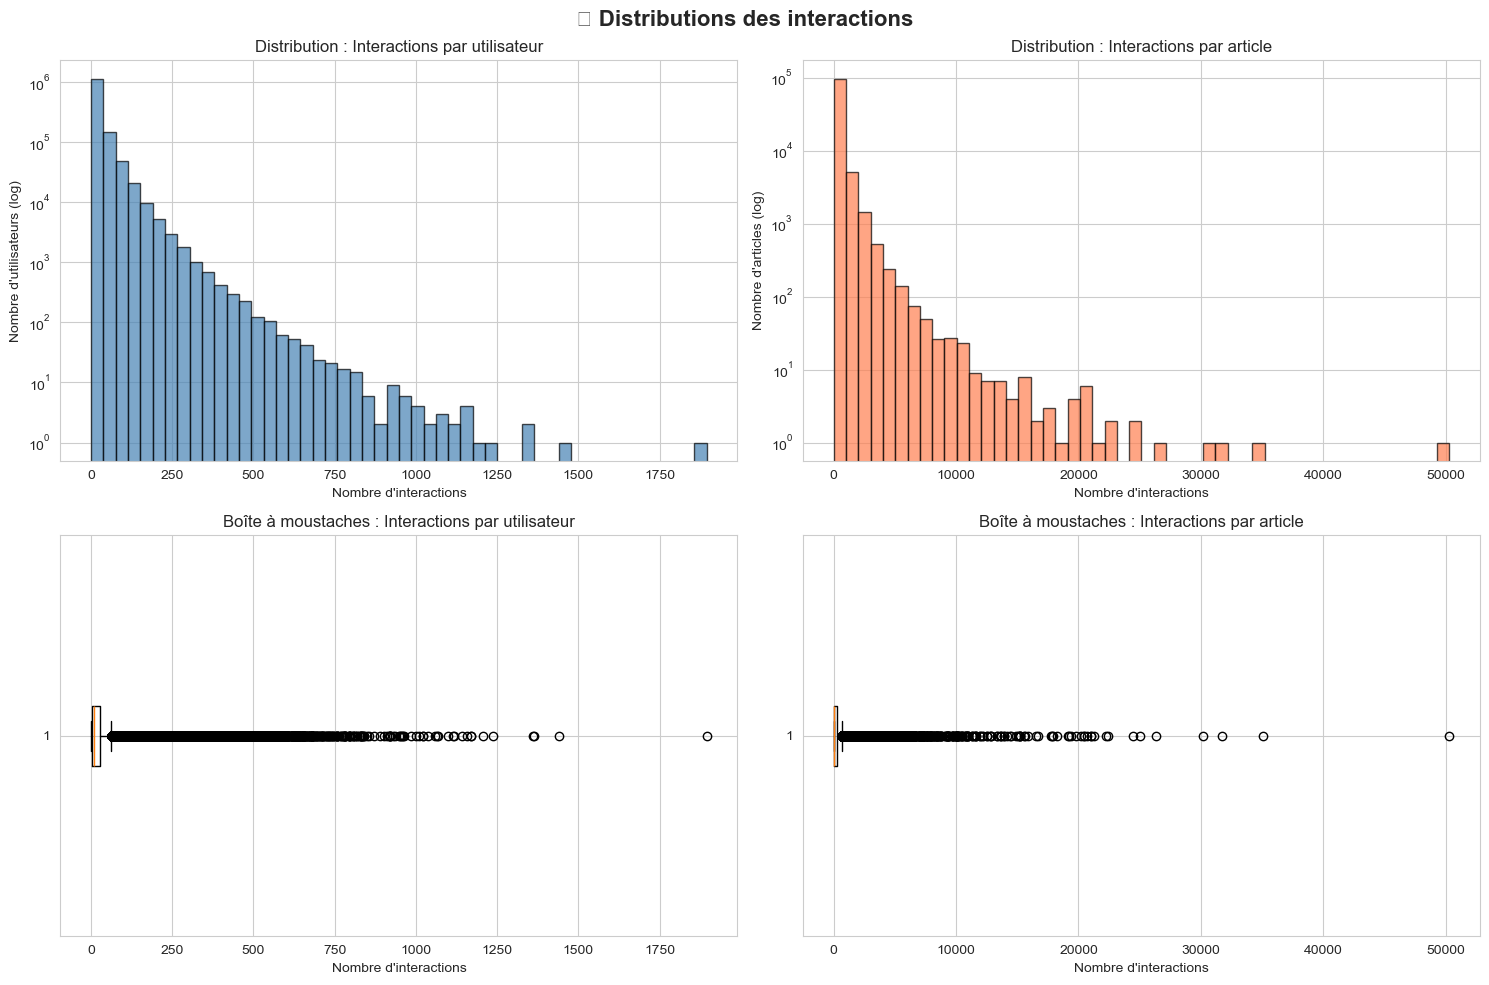


🔗 ANALYSE DE LA LONGUE TRAÎNE :
  • 10% des meilleurs utilisateurs = 48.5% des interactions
  • 10% des meilleurs articles = 60.8% des interactions


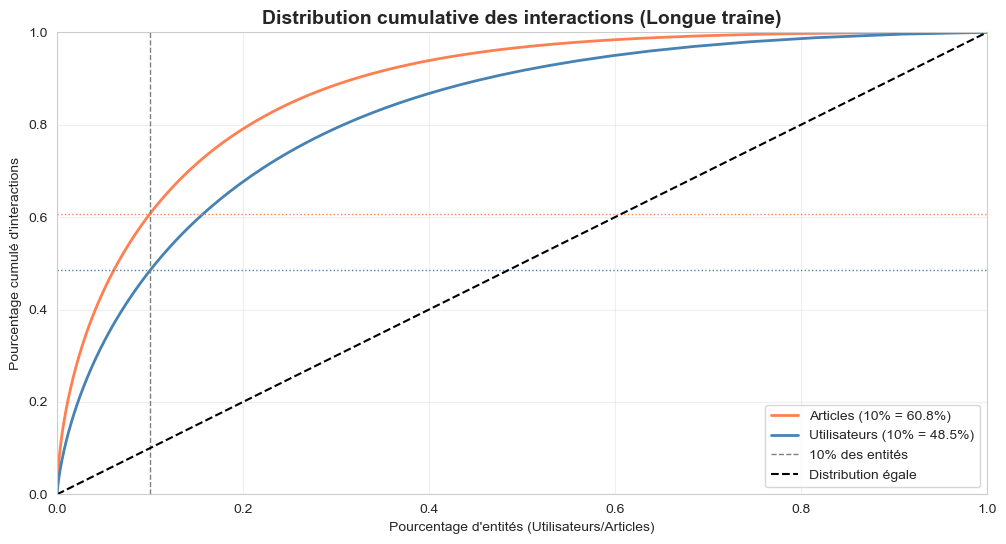


🎯 TOP 10 ARTICLES LES PLUS POPULAIRES :
   1. 50,287 interactions - Jade HW Skinny Denim TRS
   2. 35,043 interactions - Jade HW Skinny Denim TRS
   3. 31,718 interactions - 7p Basic Shaftless
   4. 30,199 interactions - Tilly (1)
   5. 26,329 interactions - Tilda tank
   6. 25,025 interactions - Greta Thong Mynta Low 3p
   7. 24,458 interactions - 7p Basic Shaftless
   8. 22,451 interactions - Tilly (1)
   9. 22,236 interactions - Curvy Jeggings HW Ankle
  10. 21,241 interactions - Jade HW Skinny Denim TRS


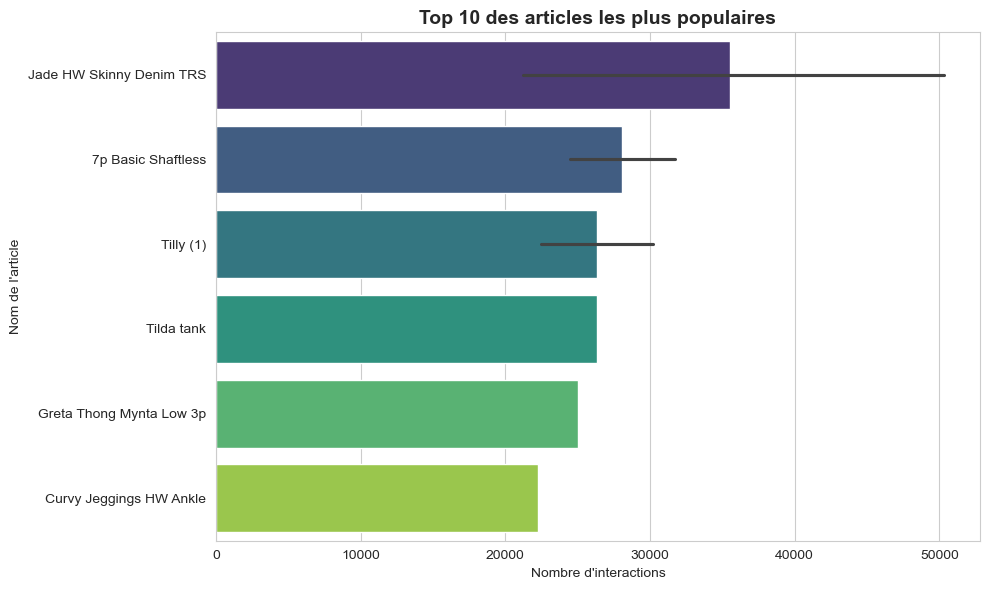


📉 ARTICLES LES MOINS POPULAIRES (1 interaction) :
  • Nombre d'articles avec 1 seule interaction : 4,491

  • Groupes de produits les plus courants (parmi les moins populaires) :
product_group_name
Garment Upper body    1897
Garment Lower body     822
Accessories            577
Garment Full body      466
Shoes                  222
Name: count, dtype: int64

  • Types de produits les plus courants (parmi les moins populaires) :
product_type_name
Trousers    446
T-shirt     396
Sweater     395
Dress       316
Jacket      215
Name: count, dtype: int64


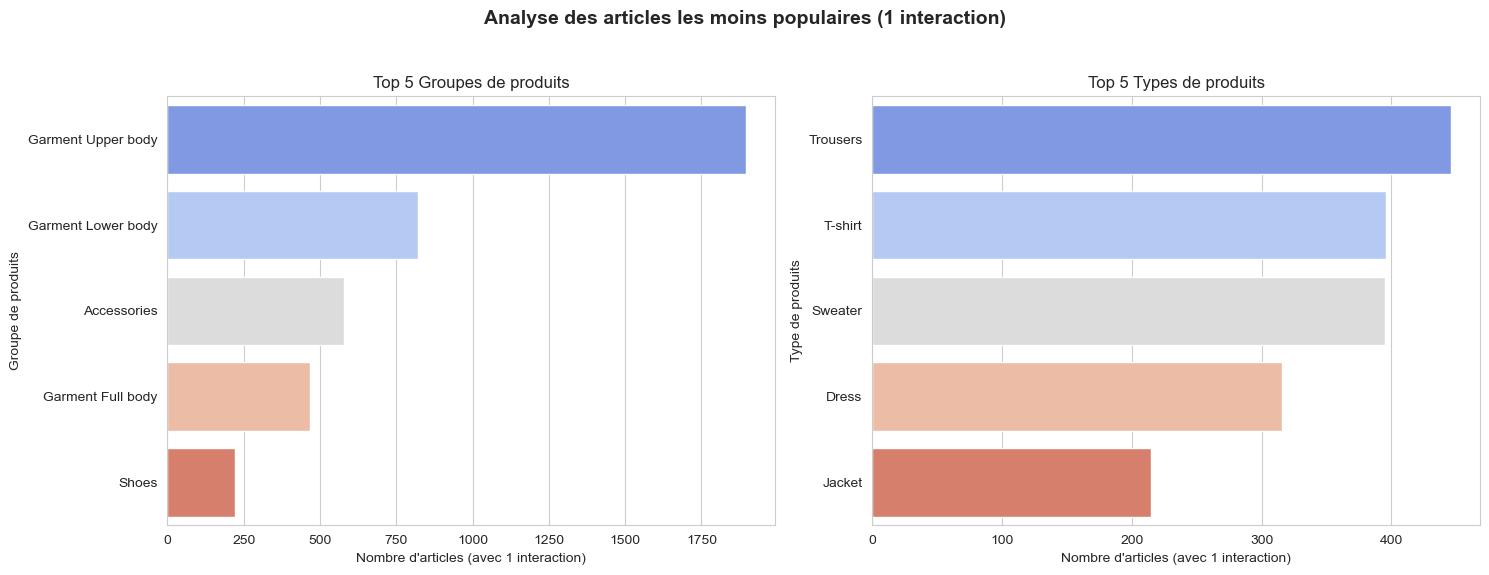


📅 ANALYSE DE SAISONNALITÉ :


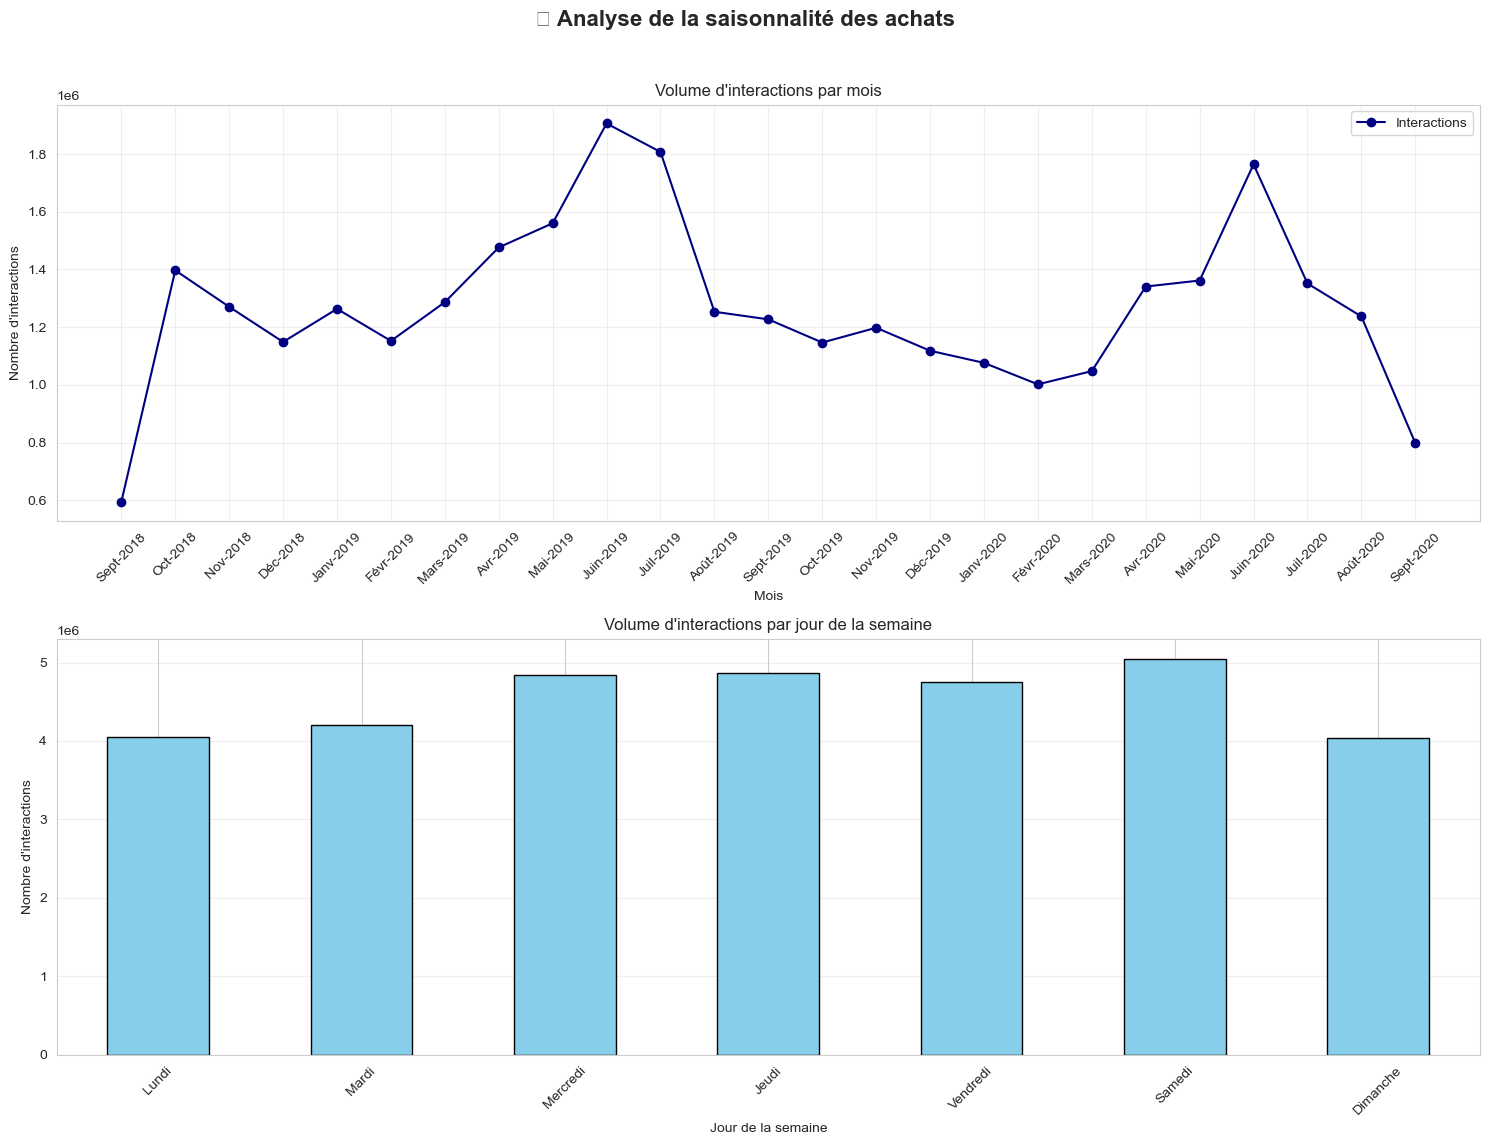

In [13]:
# [CELLULE 12 MISE À JOUR AVEC TOUS LES LABELS EN FRANÇAIS]

# 5. Distributions des interactions
print("\n📈 DISTRIBUTIONS DES INTERACTIONS :")

user_interactions = transactions.groupby('customer_id').size()
item_interactions = transactions.groupby('article_id').size()

print("\n  • Par utilisateur :")
print(user_interactions.describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n  • Par article :")
print(item_interactions.describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# 6. Visualisations (Existantes)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Distributions des interactions', fontsize=16, fontweight='bold')

# Histogrammes
axes[0, 0].hist(user_interactions, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Distribution : Interactions par utilisateur')
axes[0, 0].set_xlabel('Nombre d\'interactions')
axes[0, 0].set_ylabel('Nombre d\'utilisateurs (log)')

axes[0, 1].hist(item_interactions, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution : Interactions par article')
axes[0, 1].set_xlabel('Nombre d\'interactions')
axes[0, 1].set_ylabel('Nombre d\'articles (log)')

# Box plots
axes[1, 0].boxplot(user_interactions, vert=False)
axes[1, 0].set_title('Boîte à moustaches : Interactions par utilisateur')
axes[1, 0].set_xlabel('Nombre d\'interactions')

axes[1, 1].boxplot(item_interactions, vert=False)
axes[1, 1].set_title('Boîte à moustaches : Interactions par article')
axes[1, 1].set_xlabel('Nombre d\'interactions')

plt.tight_layout()
plt.show()

# 7. Analyse de la longue traîne
print("\n🔗 ANALYSE DE LA LONGUE TRAÎNE :")
cumulative_users = user_interactions.sort_values(ascending=False).cumsum() / user_interactions.sum()
cumulative_items = item_interactions.sort_values(ascending=False).cumsum() / item_interactions.sum()

idx_10pct_users = int(0.1 * len(cumulative_users))
idx_10pct_items = int(0.1 * len(cumulative_items))

pct_interactions_users = cumulative_users.iloc[idx_10pct_users] * 100
pct_interactions_items = cumulative_items.iloc[idx_10pct_items] * 100

print(f"  • 10% des meilleurs utilisateurs = {pct_interactions_users:.1f}% des interactions")
print(f"  • 10% des meilleurs articles = {pct_interactions_items:.1f}% des interactions")

# ============================================================================\n",
# NOUVEAU BLOC GRAPHIQUE : 7. VISUALISATION DE LA LONGUE TRAÎNE\n",
# ============================================================================\n",
plt.figure(figsize=(12, 6))
plt.title('Distribution cumulative des interactions (Longue traîne)', fontsize=14, fontweight='bold')

# Courbe pour les articles
pct_items = np.arange(1, len(cumulative_items) + 1) / len(cumulative_items)
plt.plot(pct_items, cumulative_items.values, label=f'Articles (10% = {pct_interactions_items:.1f}%)', color='coral', linewidth=2)

# Courbe pour les utilisateurs
pct_users = np.arange(1, len(cumulative_users) + 1) / len(cumulative_users)
plt.plot(pct_users, cumulative_users.values, label=f'Utilisateurs (10% = {pct_interactions_users:.1f}%)', color='steelblue', linewidth=2)

# Lignes de référence pour le 10%
plt.axvline(x=0.1, color='grey', linestyle='--', linewidth=1, label='10% des entités')
plt.axhline(y=pct_interactions_items/100, color='coral', linestyle=':', linewidth=1)
plt.axhline(y=pct_interactions_users/100, color='steelblue', linestyle=':', linewidth=1)

# Ligne d'égalité (distribution parfaite)
plt.plot([0, 1], [0, 1], 'k--', label='Distribution égale')

plt.xlabel('Pourcentage d\'entités (Utilisateurs/Articles)')
plt.ylabel('Pourcentage cumulé d\'interactions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


# 8. Top 10 articles
print(f"\n🎯 TOP 10 ARTICLES LES PLUS POPULAIRES :")
top_items = item_interactions.nlargest(10)
top_items_plot_data = [] # Pour stocker les données du graphique

for rank, (item_id, count) in enumerate(top_items.items(), 1):
    article_info = articles[articles['article_id'] == item_id]
    if not article_info.empty:
        name = article_info['prod_name'].values[0]
        print(f"  {rank:2d}. {count:6,} interactions - {name}")
        top_items_plot_data.append({'name': name, 'count': count}) # Ajout pour le graphique

# ============================================================================\n",
# NOUVEAU BLOC GRAPHIQUE : 8. VISUALISATION DES TOP 10 ARTICLES\n",
# ============================================================================\n",
if top_items_plot_data:
    plt.figure(figsize=(10, 6))
    top_items_df = pd.DataFrame(top_items_plot_data)
    sns.barplot(x='count', y='name', data=top_items_df.sort_values('count', ascending=False), palette='viridis')
    plt.title('Top 10 des articles les plus populaires', fontsize=14, fontweight='bold')
    plt.xlabel('Nombre d\'interactions')
    plt.ylabel('Nom de l\'article')
    plt.tight_layout()
    plt.show()


# ============================================================================\n",
# SECTION 9 : INSPECTION DES ARTICLES LES MOINS POPULAIRES\n",
# ============================================================================\n",
print("\n📉 ARTICLES LES MOINS POPULAIRES (1 interaction) :")
least_popular_items_ids = item_interactions[item_interactions == 1].index
print(f"  • Nombre d'articles avec 1 seule interaction : {len(least_popular_items_ids):,}")

# Fusionner pour obtenir les détails
least_popular_details = articles[articles['article_id'].isin(least_popular_items_ids)]

if not least_popular_details.empty:
    print("\n  • Groupes de produits les plus courants (parmi les moins populaires) :")
    least_group_counts = least_popular_details['product_group_name'].value_counts().nlargest(5)
    print(least_group_counts)

    print("\n  • Types de produits les plus courants (parmi les moins populaires) :")
    least_type_counts = least_popular_details['product_type_name'].value_counts().nlargest(5)
    print(least_type_counts)

    # ============================================================================\n",
    # NOUVEAU BLOC GRAPHIQUE : 9. VISUALISATION DES ARTICLES MOINS POPULAIRES\n",
    # ============================================================================\n",
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Analyse des articles les moins populaires (1 interaction)', fontsize=14, fontweight='bold')

    sns.barplot(x=least_group_counts.values, y=least_group_counts.index, ax=axes[0], palette='coolwarm')
    axes[0].set_title('Top 5 Groupes de produits')
    axes[0].set_xlabel('Nombre d\'articles (avec 1 interaction)')
    axes[0].set_ylabel('Groupe de produits')

    sns.barplot(x=least_type_counts.values, y=least_type_counts.index, ax=axes[1], palette='coolwarm')
    axes[1].set_title('Top 5 Types de produits')
    axes[1].set_xlabel('Nombre d\'articles (avec 1 interaction)')
    axes[1].set_ylabel('Type de produits')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("  • Aucune information trouvée pour les articles les moins populaires.")

# ============================================================================\n",
# SECTION 10 : ANALYSE DE SAISONNALITÉ (MISE À JOUR)\n",
# ============================================================================\n",
print("\n📅 ANALYSE DE SAISONNALITÉ :")

# Assurer que t_dat est bien au format datetime (normalement fait au chargement)
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 10.1. Agrégation par mois (MODIFIÉ)
# Convertit les dates en périodes mensuelles (ex: '2018-09')
monthly_interactions_period = transactions.groupby(transactions['t_dat'].dt.to_period('M')).size()
# Reconvertit l'index en timestamp pour l'extraction
monthly_interactions = monthly_interactions_period.to_timestamp()

# Dictionnaire de mapping des mois
french_months = {
    1: 'Janv', 2: 'Févr', 3: 'Mars', 4: 'Avr', 5: 'Mai', 6: 'Juin',
    7: 'Juil', 8: 'Août', 9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Déc'
}
# Créer les nouvelles étiquettes (ex: "Sept-2018")
new_index_fr = monthly_interactions.index.month.map(french_months) + '-' + monthly_interactions.index.year.astype(str)
monthly_interactions.index = new_index_fr


# 10.2. Agrégation par jour de la semaine
dow_interactions = transactions.groupby(transactions['t_dat'].dt.day_name()).size()
# Réorganiser les jours dans l'ordre correct
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_interactions = dow_interactions.reindex(days_order)

# 10.3. Visualisation de la saisonnalité (MODIFIÉ)
fig_season, axes_season = plt.subplots(2, 1, figsize=(15, 12))
fig_season.suptitle('📅 Analyse de la saisonnalité des achats', fontsize=16, fontweight='bold')

# Graphique des interactions mensuelles
axes_season[0].plot(monthly_interactions.index, monthly_interactions.values, marker='o', linestyle='-', color='navy', label='Interactions')
axes_season[0].set_title('Volume d\'interactions par mois')
axes_season[0].set_xlabel('Mois')
axes_season[0].set_ylabel('Nombre d\'interactions')
axes_season[0].grid(True, alpha=0.3)
axes_season[0].legend()
# Rotation des étiquettes de l'axe X pour une meilleure lisibilité
axes_season[0].tick_params(axis='x', rotation=45)

# Graphique des interactions par jour de la semaine
dow_interactions.plot(kind='bar', ax=axes_season[1], color='skyblue', edgecolor='black')
axes_season[1].set_title('Volume d\'interactions par jour de la semaine')
axes_season[1].set_xlabel('Jour de la semaine')
axes_season[1].set_ylabel('Nombre d\'interactions')
# Traduire les labels de l'axe X
days_order_fr = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
axes_season[1].set_xticklabels(days_order_fr)
axes_season[1].tick_params(axis='x', rotation=45)
axes_season[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajuster pour le suptitle
plt.show()

Statistiques des interactions par article :
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64


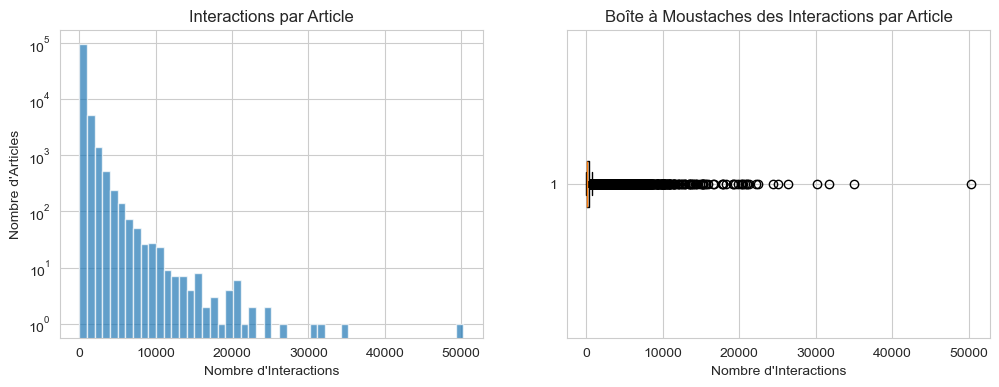

In [14]:
# Distribution des interactions par article
item_interactions = transactions.groupby('article_id').size()
print("Statistiques des interactions par article :")
print(item_interactions.describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(item_interactions, bins=50, alpha=0.7)
plt.title('Interactions par Article')
plt.xlabel('Nombre d\'Interactions')
plt.ylabel('Nombre d\'Articles')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.boxplot(item_interactions, vert=False)
plt.title('Boîte à Moustaches des Interactions par Article')
plt.xlabel('Nombre d\'Interactions')
plt.show()

In [15]:
# Analyse de la longue traîne
cumulative_users = user_interactions.sort_values(ascending=False).cumsum() / user_interactions.sum()
cumulative_items = item_interactions.sort_values(ascending=False).cumsum() / item_interactions.sum()

print("Pourcentage d'interactions des 10% meilleurs utilisateurs :", cumulative_users.iloc[int(0.1 * len(cumulative_users))])
print("Pourcentage d'interactions des 10% meilleurs articles :", cumulative_items.iloc[int(0.1 * len(cumulative_items))])

# Articles les plus populaires
print("Top 10 des articles les plus populaires :")
top_items = item_interactions.nlargest(10)
for idx, count in top_items.items():
    # Utiliser .loc pour une indexation plus sûre et efficace
    article_info = articles.loc[articles['article_id'] == idx]
    if not article_info.empty:
        print(f"Article {idx} : {count} interactions - {article_info['prod_name'].values[0]}")

Pourcentage d'interactions des 10% meilleurs utilisateurs : 0.48469397128329256
Pourcentage d'interactions des 10% meilleurs articles : 0.6075121167130422
Top 10 des articles les plus populaires :
Article 706016001 : 50287 interactions - Jade HW Skinny Denim TRS
Article 706016002 : 35043 interactions - Jade HW Skinny Denim TRS
Article 372860001 : 31718 interactions - 7p Basic Shaftless
Article 610776002 : 30199 interactions - Tilly (1)
Article 759871002 : 26329 interactions - Tilda tank
Article 464297007 : 25025 interactions - Greta Thong Mynta Low 3p
Article 372860002 : 24458 interactions - 7p Basic Shaftless
Article 610776001 : 22451 interactions - Tilly (1)
Article 399223001 : 22236 interactions - Curvy Jeggings HW Ankle
Article 706016003 : 21241 interactions - Jade HW Skinny Denim TRS


## 🎲 Stratégie d'Échantillonnage

**Objectif :** Créer un sous-ensemble de données gérable pour l'expérimentation tout en préservant les caractéristiques essentielles du dataset complet.

**Pourquoi l'échantillonnage est-il nécessaire ?**
- Les datasets complets H&M sont trop volumineux pour l'expérimentation rapide
- Un échantillonnage intelligent permet d'itérer rapidement sur les modèles
- Préserver les distributions originales assure la représentativité des résultats

**Stratégies d'échantillonnage utilisées :**
- **Utilisateurs actifs** : Sélection des utilisateurs avec ≥5 interactions (engagement réel)
- **Articles actifs** : Sélection des articles avec ≥ 10 interactions (pour un signal minimum)
- **Tailles multiples** : Tests avec 1K, 5K, 10K utilisateurs pour évaluer l'impact

In [16]:
# ============================================================================
# STRATÉGIE D'ÉCHANTILLONNAGE
# ============================================================================
print("\n" + "=" * 70)
print("STRATÉGIE D'ÉCHANTILLONNAGE")
print("=" * 70)

# 1. Filtrer les utilisateurs et articles actifs
print("\n🔍 FILTRAGE DES UTILISATEURS ET ARTICLES ACTIFS :")
active_users = user_interactions[user_interactions >= 5].index
active_items = item_interactions[item_interactions >= 10].index

print(f"  ✓ Utilisateurs actifs (≥5 interactions) : {len(active_users):,} / {len(user_interactions):,} ({len(active_users)/len(user_interactions)*100:.1f}%)")
print(f"  ✓ Articles actifs (≥10 interactions)   : {len(active_items):,} / {len(item_interactions):,} ({len(active_items)/len(item_interactions)*100:.1f}%)")

sampled_transactions = transactions[
    transactions['customer_id'].isin(active_users) &
    transactions['article_id'].isin(active_items)
]
print(f"  ✓ Interactions filtrées : {len(sampled_transactions):,} / {len(transactions):,} ({len(sampled_transactions)/len(transactions)*100:.1f}%)")

# 2. Créer des échantillons de différentes tailles
print(f"\n🎲 CRÉATION DES ÉCHANTILLONS :")
user_sample_sizes = [1000, 10000, 50000]
#user_sample_sizes = [1000]
samples = {}
all_active_users_in_sample = sampled_transactions['customer_id'].unique()

for size in user_sample_sizes:
    np.random.seed(42)
    actual_size = min(size, len(all_active_users_in_sample))
    sample_user_ids = np.random.choice(all_active_users_in_sample, size=actual_size, replace=False)
    samples[size] = sampled_transactions[sampled_transactions['customer_id'].isin(sample_user_ids)]

    user_int = samples[size].groupby('customer_id').size()
    item_int = samples[size].groupby('article_id').size()

    print(f"\n  📦 Échantillon {size:,} utilisateurs :")
    print(f"    ├─ Utilisateurs : {samples[size]['customer_id'].nunique():,}")
    print(f"    ├─ Articles : {samples[size]['article_id'].nunique():,}")
    print(f"    ├─ Interactions : {len(samples[size]):,}")
    print(f"    ├─ Moy. interactions/utilisateur : {user_int.mean():.2f}")
    print(f"    └─ Moy. interactions/article : {item_int.mean():.2f}")

sample_sizes = user_sample_sizes
print(f"\n✅ {len(sample_sizes)} échantillons créés et prêts pour l'entraînement")


STRATÉGIE D'ÉCHANTILLONNAGE

🔍 FILTRAGE DES UTILISATEURS ET ARTICLES ACTIFS :
  ✓ Utilisateurs actifs (≥5 interactions) : 925,558 / 1,362,281 (67.9%)
  ✓ Articles actifs (≥10 interactions)   : 83,319 / 104,547 (79.7%)
  ✓ Interactions filtrées : 30,702,763 / 31,788,324 (96.6%)

🎲 CRÉATION DES ÉCHANTILLONS :

  📦 Échantillon 1,000 utilisateurs :
    ├─ Utilisateurs : 1,000
    ├─ Articles : 17,794
    ├─ Interactions : 35,666
    ├─ Moy. interactions/utilisateur : 35.67
    └─ Moy. interactions/article : 2.00

  📦 Échantillon 10,000 utilisateurs :
    ├─ Utilisateurs : 10,000
    ├─ Articles : 51,752
    ├─ Interactions : 333,779
    ├─ Moy. interactions/utilisateur : 33.38
    └─ Moy. interactions/article : 6.45

  📦 Échantillon 50,000 utilisateurs :
    ├─ Utilisateurs : 50,000
    ├─ Articles : 73,800
    ├─ Interactions : 1,665,345
    ├─ Moy. interactions/utilisateur : 33.31
    └─ Moy. interactions/article : 22.57

✅ 3 échantillons créés et prêts pour l'entraînement


In [17]:
# ============================================================================\n",
# BOUCLE PRINCIPALE : ÉTAPES 3 À 8 (PRETRAITEMENT, TRAIN, EVAL, HYBRIDE)\n",
# ============================================================================\n",
print("\n" + "=" * 70)
print("ÉTAPES 3-8 : BOUCLE PRINCIPALE D'ENTRAÎNEMENT (AVEC TEST COLD-START)")
print("=" * 70)

results_comparison = {}

for size in sample_sizes:
    print(f"\n{'#' * 70}")
    print(f"# TRAITEMENT ÉCHANTILLON : {size:,} utilisateurs")
    print(f"{'#' * 70}")

    if size not in samples:
        print(f"⚠️ Échantillon {size} non disponible. Passage...")
        continue


    data = samples[size].copy()

    try:
        start_time = time.time()
        memory_before = psutil.virtual_memory().used / (1024**2)

        # Initialiser les métriques Cold-Start
        test_auc_cs_cf = 0.0
        precision_10_cs_cf = 0.0
        hybrid_auc_cs = 0.0
        hybrid_precision_10_cs = 0.0

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 3 : PRÉTRAITEMENT & CONSTRUCTION DATASET LIGHTFM
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 3] Prétraitement & Construction Dataset LightFM")

        unique_users = data['customer_id'].unique()
        unique_items = data['article_id'].unique()

        # Préparation des features d'articles
        print("  ► Préparation des features d'articles...")
        sample_articles_df = articles[articles['article_id'].isin(unique_items)].copy()
        item_feature_cols = ['product_type_name', 'product_group_name', 'department_name', 'colour_group_name']

        for col in item_feature_cols:
            sample_articles_df[col] = sample_articles_df[col].fillna('Inconnu')

        item_features_list = []
        for _, row in sample_articles_df.iterrows():
            features = [f"{col}:{row[col]}" for col in item_feature_cols]
            item_features_list.append((row['article_id'], features))
        all_item_features = [f for _, features in item_features_list for f in features]

        # Préparation des features utilisateur
        print("  ► Préparation des features utilisateur...")
        sample_users_df = data[['customer_id']].drop_duplicates()
        sample_users_df = sample_users_df.merge(
            customers[['customer_id', 'age_bin']],
            on='customer_id',
            how='left'
        )
        if 'Inconnu' not in sample_users_df['age_bin'].cat.categories:
             sample_users_df['age_bin'] = sample_users_df['age_bin'].cat.add_categories('Inconnu')
        sample_users_df['age_bin'] = sample_users_df['age_bin'].fillna('Inconnu')

        user_feature_cols = ['age_bin']
        user_features_list = []
        for _, row in sample_users_df.iterrows():
            features = [f"{col}:{row[col]}" for col in user_feature_cols]
            user_features_list.append((row['customer_id'], features))
        all_user_features = [f for _, features in user_features_list for f in features]

        # Initialisation et Fit du Dataset
        print("  ► Initialisation et fit du Dataset LightFM (avec features)...")
        dataset = Dataset()
        dataset.fit(
            users=unique_users,
            items=unique_items,
            user_features=all_user_features,
            item_features=all_item_features
        )

        user_id_map, _, item_id_map, _ = dataset.mapping()
        user_id_reverse = {v: k for k, v in user_id_map.items()}
        item_id_reverse = {v: k for k, v in item_id_map.items()}

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 4 : DIVISION TRAIN/TEST TEMPORELLE
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 4] Division Train/Test (split temporel 80/20)")

        data_sorted = data.sort_values('t_dat')
        split_point = int(0.8 * len(data_sorted))
        train_data = data_sorted.iloc[:split_point]
        test_data = data_sorted.iloc[split_point:]

        # Binarisation et disjonction
        train_data = train_data.drop_duplicates(subset=['customer_id', 'article_id'])
        test_data = test_data.drop_duplicates(subset=['customer_id', 'article_id'])
        train_pairs_set = set(zip(train_data['customer_id'], train_data['article_id']))
        test_pairs_list = list(zip(test_data['customer_id'], test_data['article_id']))
        mask = [pair not in train_pairs_set for pair in test_pairs_list]
        test_data = test_data[mask] # test_data est maintenant le set 'Warm-Start'

        # Construction des matrices 'Warm-Start'
        print("  ► Construction des matrices train/test (Warm-Start) via Dataset...")
        train_matrix = build_interaction_matrix_with_dataset(dataset, train_data)
        test_matrix = build_interaction_matrix_with_dataset(dataset, test_data)

        print(f"  ✓ Train (Warm) : {train_matrix.nnz:,} interactions")
        print(f"  ✓ Test (Warm)  : {test_matrix.nnz:,} interactions")

        # ────────────────────────────────────────────────────────────────
        # (NOUVEAU) ÉTAPE 4.5 : CRÉATION DU SET DE TEST COLD-START
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 4.5] Création du set de Test Cold-Start (Articles)")

        items_in_train = set(train_data['article_id'].unique())
        # Nous utilisons test_data (déjà filtré) pour trouver les articles 'cold'
        items_in_test = set(test_data['article_id'].unique())

        cold_start_items = items_in_test - items_in_train

        # Le test_data_cs_df ne contient que les interactions avec ces nouveaux articles
        test_data_cs_df = test_data[test_data['article_id'].isin(cold_start_items)]

        # Construire la matrice de test cold-start
        test_matrix_cs = build_interaction_matrix_with_dataset(dataset, test_data_cs_df)

        print(f"  ✓ Items dans Train : {len(items_in_train):,}")
        print(f"  ✓ Items Cold-Start (uniquement dans Test) : {len(cold_start_items):,}")
        print(f"  ✓ Interactions Test (Cold-Start) : {test_matrix_cs.nnz:,}")


        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 5 : ENTRAÎNEMENT DES MODÈLES (FILTRAGE COLLABORATIF)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 5] Entraînement Modèles CF (Filtrage Collaboratif)")

        loss_functions = ['warp', 'bpr', 'logistic']
        # Note: Les modèles sont évalués sur le test_matrix (warm-start) pour trouver le meilleur
        models, scores = train_models(train_matrix, test_matrix, loss_functions)
        best_loss = max(scores, key=lambda x: scores[x]['test_auc'])

        print(f"\n  🏆 Meilleure fonction de perte : {best_loss.upper()} (basé sur Warm-Start)")

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 6 : OPTIMISATION DES HYPERPARAMÈTRES (CF)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 6] Optimisation Hyperparamètres (CF)")

        best_model_cf, best_params_cf, test_auc_cf = optimize_hyperparameters(
            train_matrix, test_matrix, best_loss
        )

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 7 : ÉVALUATION DU MODÈLE CF (WARM-START)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 7] Évaluation Modèle CF (Warm-Start)")

        precision_10_cf = precision_at_k(
            best_model_cf, test_matrix, train_interactions=train_matrix, k=10, num_threads=psutil.cpu_count()
        ).mean()
        recall_10_cf = recall_at_k(
            best_model_cf, test_matrix, train_interactions=train_matrix, k=10, num_threads=psutil.cpu_count()
        ).mean()

        print(f"  ✓ AUC (Warm) :       {test_auc_cf:.4f}")
        print(f"  ✓ Precision@10 (Warm): {precision_10_cf:.4f}")
        print(f"  ✓ Recall@10 (Warm) :   {recall_10_cf:.4f}")

        # ────────────────────────────────────────────────────────────────
        # (NOUVEAU) ÉTAPE 7.5 : ÉVALUATION COLD-START (CF)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 7.5] Évaluation Cold-Start (CF)")

        if test_matrix_cs.nnz > 0:
            test_auc_cs_cf = auc_score(
                best_model_cf, test_matrix_cs, train_interactions=train_matrix, num_threads=psutil.cpu_count()
            ).mean()
            precision_10_cs_cf = precision_at_k(
                best_model_cf, test_matrix_cs, train_interactions=train_matrix, k=10, num_threads=psutil.cpu_count()
            ).mean()
            print(f"  ✓ AUC (Cold-Start) :       {test_auc_cs_cf:.4f}")
            print(f"  ✓ Precision@10 (Cold-Start): {precision_10_cs_cf:.4f}")
        else:
            print("  ✓ Pas d'interactions cold-start à évaluer pour le CF.")

        # ────────────────────────────────────────────────────────────────
        # ÉTAPE 8 : MODÈLE HYBRIDE (CF + FEATURES)
        # ────────────────────────────────────────────────────────────────
        print("\n[ÉTAPE 8] Construction & Évaluation Modèle Hybride")

        print("  ► Construction des matrices de features...")
        item_features_matrix = dataset.build_item_features(item_features_list, normalize=False)
        user_features_matrix = dataset.build_user_features(user_features_list, normalize=False)

        print(f"    ├─ Features articles : {item_features_matrix.shape}")
        print(f"    └─ Features utilisateurs : {user_features_matrix.shape}")

        print("  ► Entraînement du modèle hybride...")
        hybrid_model = LightFM(
            no_components=best_params_cf.get('no_components', 30),
            learning_rate=best_params_cf.get('learning_rate', 0.05),
            loss=best_loss,
            random_state=42
        )
        hybrid_model.fit(
            train_matrix,
            item_features=item_features_matrix,
            user_features=user_features_matrix,
            epochs=10,
            verbose=True,
            num_threads=psutil.cpu_count()
        )

        # Évaluation Hybride (Warm-Start)
        print("\n  ► Évaluation Hybride (Warm-Start)")
        hybrid_auc = auc_score(
            hybrid_model, test_matrix, train_interactions=train_matrix,
            item_features=item_features_matrix, user_features=user_features_matrix,
            num_threads=psutil.cpu_count()
        ).mean()
        hybrid_precision_10 = precision_at_k(
            hybrid_model, test_matrix, train_interactions=train_matrix,
            item_features=item_features_matrix, user_features=user_features_matrix,
            k=10, num_threads=psutil.cpu_count()
        ).mean()
        hybrid_recall_10 = recall_at_k(
            hybrid_model, test_matrix, train_interactions=train_matrix,
            item_features=item_features_matrix, user_features=user_features_matrix,
            k=10, num_threads=psutil.cpu_count()
        ).mean()

        print(f"  ✓ AUC (Warm) :         {hybrid_auc:.4f}")
        print(f"  ✓ Precision@10 (Warm) : {hybrid_precision_10:.4f}")
        print(f"  ✓ Recall@10 (Warm) :    {hybrid_recall_10:.4f}")

        # ────────────────────────────────────────────────────────────────
        # (NOUVEAU) ÉTAPE 8.5 : ÉVALUATION COLD-START (HYBRIDE)
        # ────────────────────────────────────────────────────────────────
        print("\n  ► Évaluation Hybride (Cold-Start)")

        if test_matrix_cs.nnz > 0:
            hybrid_auc_cs = auc_score(
                hybrid_model, test_matrix_cs, train_interactions=train_matrix,
                item_features=item_features_matrix, user_features=user_features_matrix,
                num_threads=psutil.cpu_count()
            ).mean()
            hybrid_precision_10_cs = precision_at_k(
                hybrid_model, test_matrix_cs, train_interactions=train_matrix,
                item_features=item_features_matrix, user_features=user_features_matrix,
                k=10, num_threads=psutil.cpu_count()
            ).mean()
            print(f"  ✓ AUC (Cold-Start) :         {hybrid_auc_cs:.4f}")
            print(f"  ✓ Precision@10 (Cold-Start) : {hybrid_precision_10_cs:.4f}")
        else:
            print("  ✓ Pas d'interactions cold-start à évaluer pour l'Hybride.")

        # ────────────────────────────────────────────────────────────────
        # STOCKAGE DES RÉSULTATS
        # ────────────────────────────────────────────────────────────────
        train_time_total = time.time() - start_time
        memory_after = psutil.virtual_memory().used / (1024**2)
        memory_usage = memory_after - memory_before

        results_comparison[size] = {
            'n_users': len(unique_users),
            'n_items': len(unique_items),
            'best_loss': best_loss,
            'best_params': best_params_cf,
            'cf_test_auc': test_auc_cf,
            'cf_precision@10': precision_10_cf,
            'cf_recall@10': recall_10_cf,
            'hybrid_test_auc': hybrid_auc,
            'hybrid_precision@10': hybrid_precision_10,
            'hybrid_recall@10': hybrid_recall_10,
            'cf_auc_cold': test_auc_cs_cf,
            'cf_prec10_cold': precision_10_cs_cf,
            'hybrid_auc_cold': hybrid_auc_cs,
            'hybrid_prec10_cold': hybrid_precision_10_cs,
            'train_time': train_time_total,
            'memory_mb': memory_usage
        }

        print(f"\n✅ Échantillon {size:,} traité avec succès en {train_time_total:.2f}s")

    except MemoryError:
        print(f"\n❌ ERREUR : Mémoire insuffisante pour {size:,} utilisateurs")
        continue
    except Exception as e:
        print(f"\n❌ ERREUR pour {size:,} : {str(e)}")
        continue

print("\n" + "=" * 70)
print("✅ BOUCLE PRINCIPALE TERMINÉE")
print("=" * 70)


ÉTAPES 3-8 : BOUCLE PRINCIPALE D'ENTRAÎNEMENT (AVEC TEST COLD-START)

######################################################################
# TRAITEMENT ÉCHANTILLON : 1,000 utilisateurs
######################################################################

[ÉTAPE 3] Prétraitement & Construction Dataset LightFM
  ► Préparation des features d'articles...
  ► Préparation des features utilisateur...
  ► Initialisation et fit du Dataset LightFM (avec features)...

[ÉTAPE 4] Division Train/Test (split temporel 80/20)
  ► Construction des matrices train/test (Warm-Start) via Dataset...
  ✓ Train (Warm) : 24,234 interactions
  ✓ Test (Warm)  : 6,103 interactions

[ÉTAPE 4.5] Création du set de Test Cold-Start (Articles)
  ✓ Items dans Train : 14,640
  ✓ Items Cold-Start (uniquement dans Test) : 3,154
  ✓ Interactions Test (Cold-Start) : 4,237

[ÉTAPE 5] Entraînement Modèles CF (Filtrage Collaboratif)

  ► Entraînement avec perte WARP...
Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 

In [18]:
# ============================================================================
# BONUS : FONCTION POUR GÉNÉRER DES RECOMMANDATIONS POUR UN UTILISATEUR
# ============================================================================

def get_recommendations(user_id, model, user_id_map, item_id_reverse, n_recommendations=10):
    """
    Génère des recommandations pour un utilisateur spécifique.

    Args:
        user_id: ID du client original
        model: Modèle LightFM entraîné
        user_id_map: Mapping utilisateur → index
        item_id_reverse: Mapping index → ID article
        n_recommendations: Nombre de recommandations

    Returns:
        list: Liste des IDs articles recommandés
    """
    if user_id not in user_id_map:
        return None

    user_internal_id = user_id_map[user_id]

    # Prédire les scores pour tous les articles
    scores = model.predict(
        user_internal_id,
        np.arange(len(item_id_reverse))
    )

    # Obtenir les top N articles
    top_items_internal = np.argsort(-scores)[:n_recommendations]
    top_items_original = [item_id_reverse[i] for i in top_items_internal]

    return top_items_original


# Exemple d'utilisation (décommentez pour tester)
# print("\n" + "=" * 70)
# print("EXEMPLE : RECOMMANDATIONS POUR UN UTILISATEUR")
# print("=" * 70)
#
# user_id_to_test = list(user_id_map.keys())[0]
# recommendations = get_recommendations(user_id_to_test, best_model_cf, user_id_map, item_id_reverse)
#
# if recommendations:
#     print(f"\n👤 Recommandations pour l'utilisateur {user_id_to_test} :")
#     for rank, item_id in enumerate(recommendations, 1):
#         article_info = articles[articles['article_id'] == item_id]
#         if not article_info.empty:
#             name = article_info['prod_name'].values[0]
#             print(f"  {rank:2d}. {name}")


ANALYSE COMPARATIVE DES RÉSULTATS (AVEC COLD-START)

📊 TABLEAU RÉCAPITULATIF :
      n_users best_loss cf_test_auc hybrid_test_auc cf_auc_cold  \
1000     1000       bpr     0.49567        0.624403     0.48347   
10000   10000      warp    0.506241        0.591007    0.192175   
50000   50000      warp    0.567918        0.643721    0.169019   

      hybrid_auc_cold cf_precision@10 hybrid_precision@10 cf_prec10_cold  \
1000         0.618635        0.001144            0.002451            0.0   
10000        0.347422         0.00413            0.004295            0.0   
50000        0.347445        0.004473            0.004499            0.0   

      hybrid_prec10_cold   train_time  
1000            0.001188    16.781139  
10000                0.0   405.181186  
50000                0.0  2785.600344  


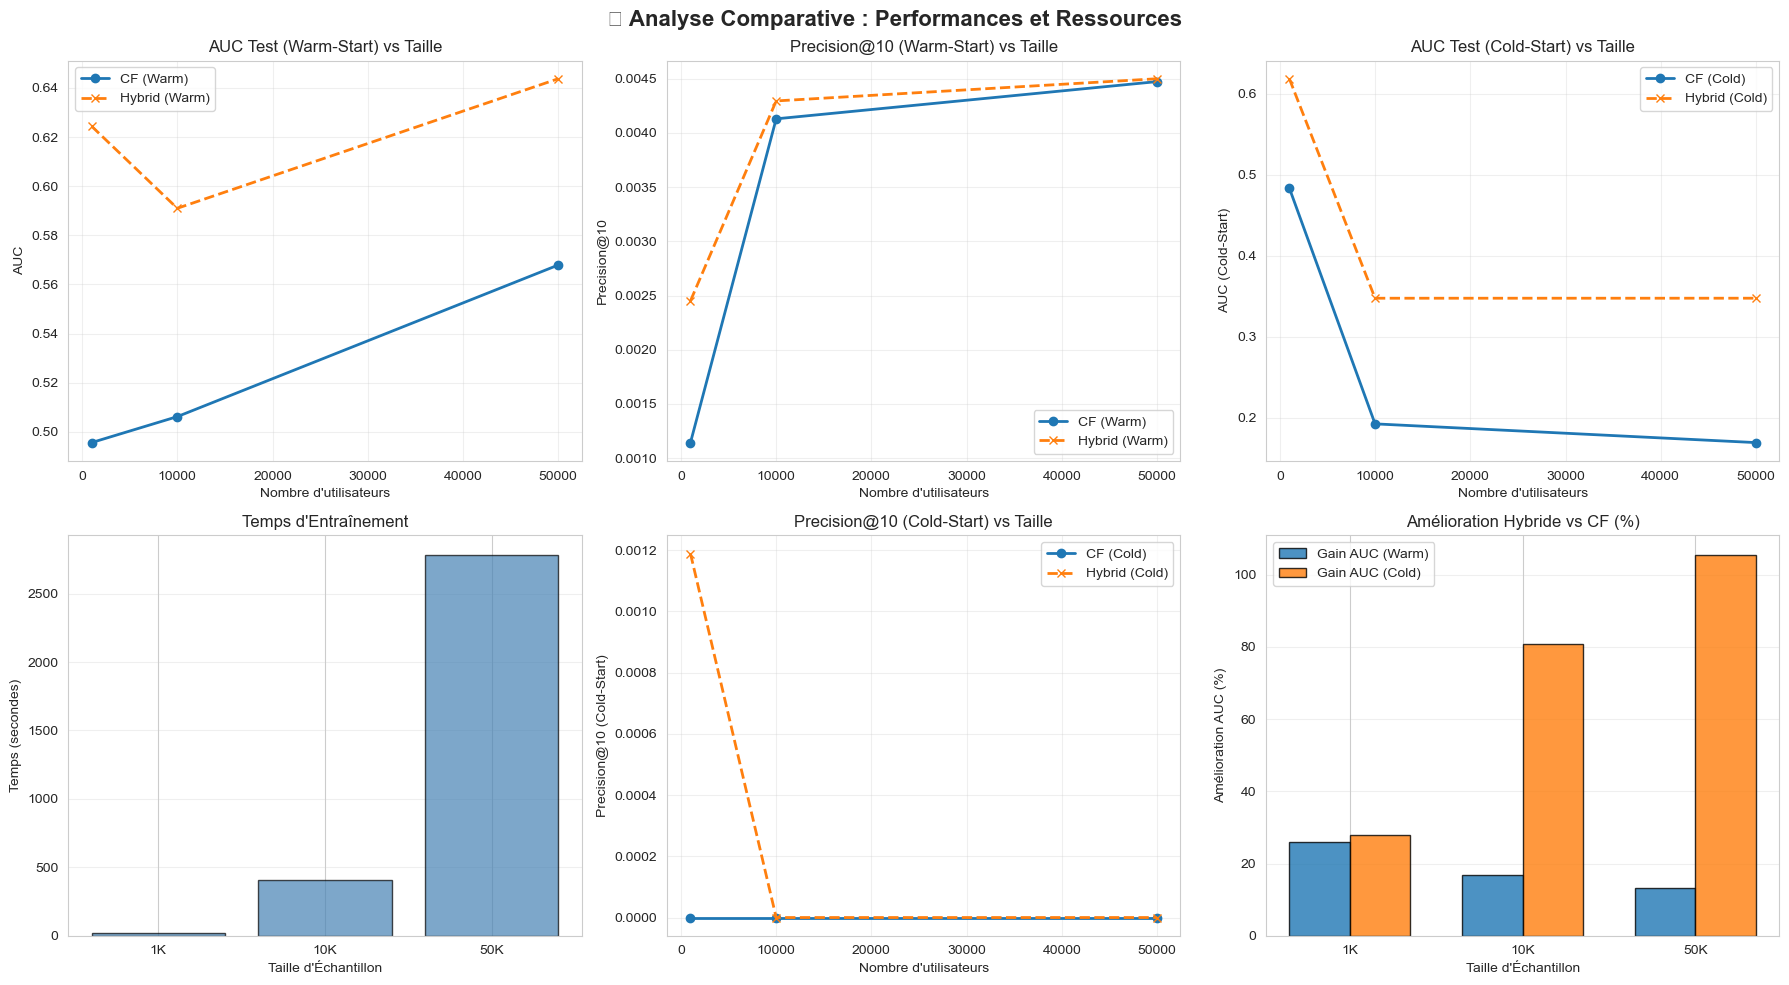


📈 INSIGHTS CLÉS (AVEC COLD-START) :

✓ Gain moyen d'AUC (Hybride vs CF) [Warm-Start] : +0.0964
✓ Gain moyen d'AUC (Hybride vs CF) [Cold-Start] : +71.44 %
✓ Meilleure config (AUC Warm) : 50,000 utilisateurs (Hybride)
✓ Meilleure config (AUC Cold) : 1,000 utilisateurs (Hybride)
✓ Meilleure perte :             bpr


In [24]:
# ============================================================================\n",
# ANALYSE COMPARATIVE : IMPACT DE LA TAILLE D'ÉCHANTILLON\n",
# ============================================================================\n",
print("\n" + "=" * 70)
print("ANALYSE COMPARATIVE DES RÉSULTATS (AVEC COLD-START)")
print("=" * 70)

# Créer le DataFrame des résultats
df_results = pd.DataFrame(results_comparison).T

print("\n📊 TABLEAU RÉCAPITULATIF :")
# Colonnes mises à jour pour inclure le cold-start
columns_to_show = [
    'n_users', 'best_loss',
    'cf_test_auc', 'hybrid_test_auc',
    'cf_auc_cold', 'hybrid_auc_cold',
    'cf_precision@10', 'hybrid_precision@10',
    'cf_prec10_cold', 'hybrid_prec10_cold',
    'train_time'
]
# S'assurer que les colonnes existent avant de les afficher (au cas où une étape aurait échoué)
df_results_display = df_results[[col for col in columns_to_show if col in df_results.columns]]
print(df_results_display)

# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Analyse Comparative : Performances et Ressources', fontsize=16, fontweight='bold')

# Plot 1: AUC Comparison (Warm-Start)
axes[0, 0].plot(df_results.index, df_results['cf_test_auc'], marker='o', linewidth=2, label='CF (Warm)')
axes[0, 0].plot(df_results.index, df_results['hybrid_test_auc'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Warm)')
axes[0, 0].set_title('AUC Test (Warm-Start) vs Taille')
axes[0, 0].set_xlabel('Nombre d\'utilisateurs')
axes[0, 0].set_ylabel('AUC')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Precision@10 Comparison (Warm-Start)
axes[0, 1].plot(df_results.index, df_results['cf_precision@10'], marker='o', linewidth=2, label='CF (Warm)')
axes[0, 1].plot(df_results.index, df_results['hybrid_precision@10'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Warm)')
axes[0, 1].set_title('Precision@10 (Warm-Start) vs Taille')
axes[0, 1].set_xlabel('Nombre d\'utilisateurs')
axes[0, 1].set_ylabel('Precision@10')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: (NOUVEAU) AUC Comparison (Cold-Start)
axes[0, 2].plot(df_results.index, df_results['cf_auc_cold'], marker='o', linewidth=2, label='CF (Cold)')
axes[0, 2].plot(df_results.index, df_results['hybrid_auc_cold'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Cold)')
axes[0, 2].set_title('AUC Test (Cold-Start) vs Taille')
axes[0, 2].set_xlabel('Nombre d\'utilisateurs')
axes[0, 2].set_ylabel('AUC (Cold-Start)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)


# Plot 4: Temps d'entraînement
axes[1, 0].bar(range(len(df_results)), df_results['train_time'], color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(df_results)))
axes[1, 0].set_xticklabels([f"{int(x/1000)}K" for x in df_results.index])
axes[1, 0].set_title('Temps d\'Entraînement')
axes[1, 0].set_xlabel('Taille d\'Échantillon')
axes[1, 0].set_ylabel('Temps (secondes)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: (NOUVEAU) Precision@10 Comparison (Cold-Start)
axes[1, 1].plot(df_results.index, df_results['cf_prec10_cold'], marker='o', linewidth=2, label='CF (Cold)')
axes[1, 1].plot(df_results.index, df_results['hybrid_prec10_cold'], marker='x', linewidth=2, linestyle='--', label='Hybrid (Cold)')
axes[1, 1].set_title('Precision@10 (Cold-Start) vs Taille')
axes[1, 1].set_xlabel('Nombre d\'utilisateurs')
axes[1, 1].set_ylabel('Precision@10 (Cold-Start)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Amélioration Hybride (Warm vs Cold)
improvement_auc_warm = ((df_results['hybrid_test_auc'] - df_results['cf_test_auc']) / df_results['cf_test_auc'] * 100)
improvement_auc_cold = ((df_results['hybrid_auc_cold'] - df_results['cf_auc_cold']) / df_results['cf_auc_cold'] * 100)

x_pos = np.arange(len(improvement_auc_warm))
width = 0.35

axes[1, 2].bar(x_pos - width/2, improvement_auc_warm, width, label='Gain AUC (Warm)', alpha=0.8, edgecolor='black')
axes[1, 2].bar(x_pos + width/2, improvement_auc_cold, width, label='Gain AUC (Cold)', alpha=0.8, edgecolor='black')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels([f"{int(x/1000)}K" for x in df_results.index])
axes[1, 2].set_title('Amélioration Hybride vs CF (%)')
axes[1, 2].set_xlabel('Taille d\'Échantillon')
axes[1, 2].set_ylabel('Amélioration AUC (%)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')
axes[1, 2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('analysis_results_with_coldstart.png', dpi=300, bbox_inches='tight')
plt.show()

# Insights automatiques
print("\n" + "=" * 70)
print("📈 INSIGHTS CLÉS (AVEC COLD-START) :")
print("=" * 70)

if len(df_results) > 0:
    auc_gains_warm = df_results['hybrid_test_auc'] - df_results['cf_test_auc']
    # Éviter la division par zéro si l'AUC CF (Cold) est 0
    df_results['cf_auc_cold'] = df_results['cf_auc_cold'].replace(0, 1e-6)
    auc_gains_cold_pct = ((df_results['hybrid_auc_cold'] - df_results['cf_auc_cold']) / df_results['cf_auc_cold'] * 100)

    print(f"\n✓ Gain moyen d'AUC (Hybride vs CF) [Warm-Start] : {auc_gains_warm.mean():+.4f}")
    print(f"✓ Gain moyen d'AUC (Hybride vs CF) [Cold-Start] : {auc_gains_cold_pct.mean():+.2f} %")
    print(f"✓ Meilleure config (AUC Warm) : {df_results['hybrid_test_auc'].idxmax():,} utilisateurs (Hybride)")
    print(f"✓ Meilleure config (AUC Cold) : {df_results['hybrid_auc_cold'].idxmax():,} utilisateurs (Hybride)")
    print(f"✓ Meilleure perte :             {df_results['best_loss'].iloc[0]}")
else:
    print("⚠️ Pas assez de données pour les insights")

## RECALL@K ET PRECISION@K, VARIATION DE K

Dans cette section, nous complétons l'évaluation en ajoutant:
- Recall@K et NDCG@K en plus de Precision@K et AUC
- Une analyse pour K ∈ {5, 10, 20}

Nous réutiliserons les meilleurs modèles trouvés précédemment (CF et Hybride) lorsque disponibles dans le contexte courant (dernière taille d'échantillon exécutée).


Début de l'évaluation complémentaire (Recall@K, Precision@K) pour K={5, 10, 20}...
Utilisation des modèles du dernier échantillon entraîné.

--- Évaluation WARM-START (Articles connus) ---
Calcul des métriques @5...
Calcul des métriques @10...
Calcul des métriques @20...

--- Évaluation COLD-START (Articles inconnus) ---
Calcul des métriques @5 (Cold-Start)...
Calcul des métriques @10 (Cold-Start)...
Calcul des métriques @20 (Cold-Start)...

📊 RÉSULTATS WARM-START (K=5, 10, 20)
|                                 |       5 |      10 |      20 |
|:--------------------------------|--------:|--------:|--------:|
| ('CF (Warm)', 'Precision')      | 0.00490 | 0.00447 | 0.00383 |
| ('CF (Warm)', 'Recall')         | 0.00331 | 0.00623 | 0.01040 |
| ('Hybride (Warm)', 'Precision') | 0.00538 | 0.00450 | 0.00367 |
| ('Hybride (Warm)', 'Recall')    | 0.00373 | 0.00607 | 0.00963 |

📊 RÉSULTATS COLD-START (K=5, 10, 20)
|                                 |       5 |      10 |      20 |
|:---------------

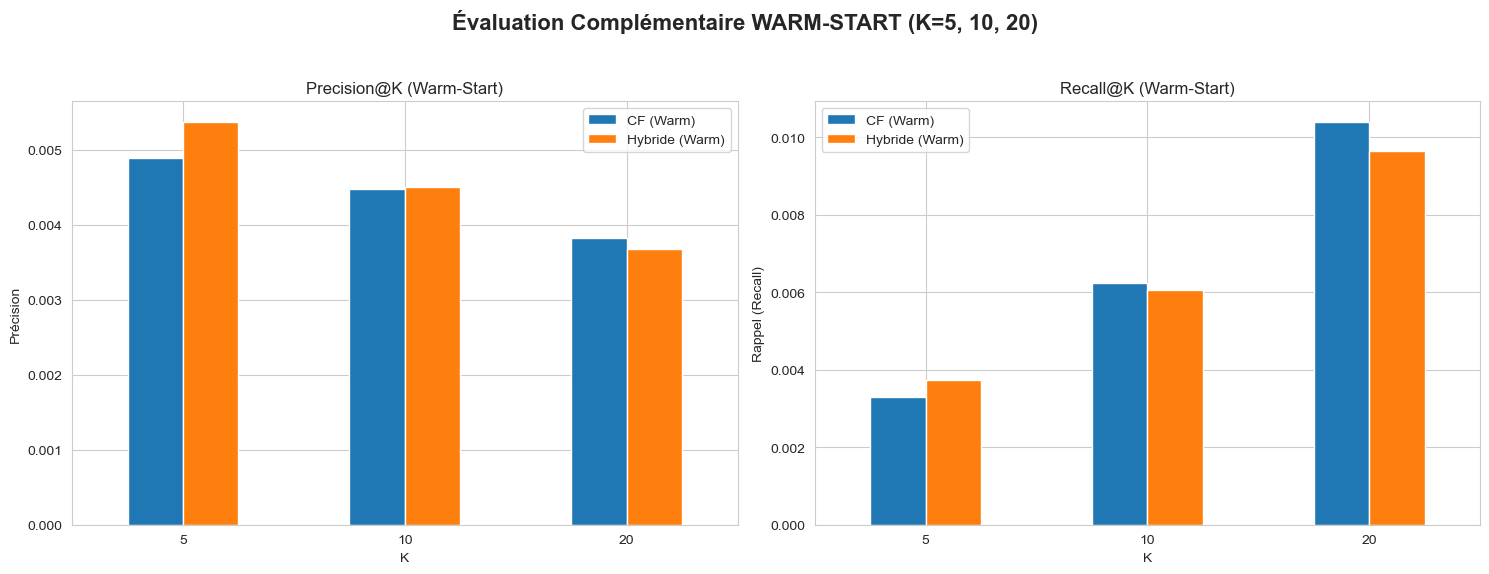

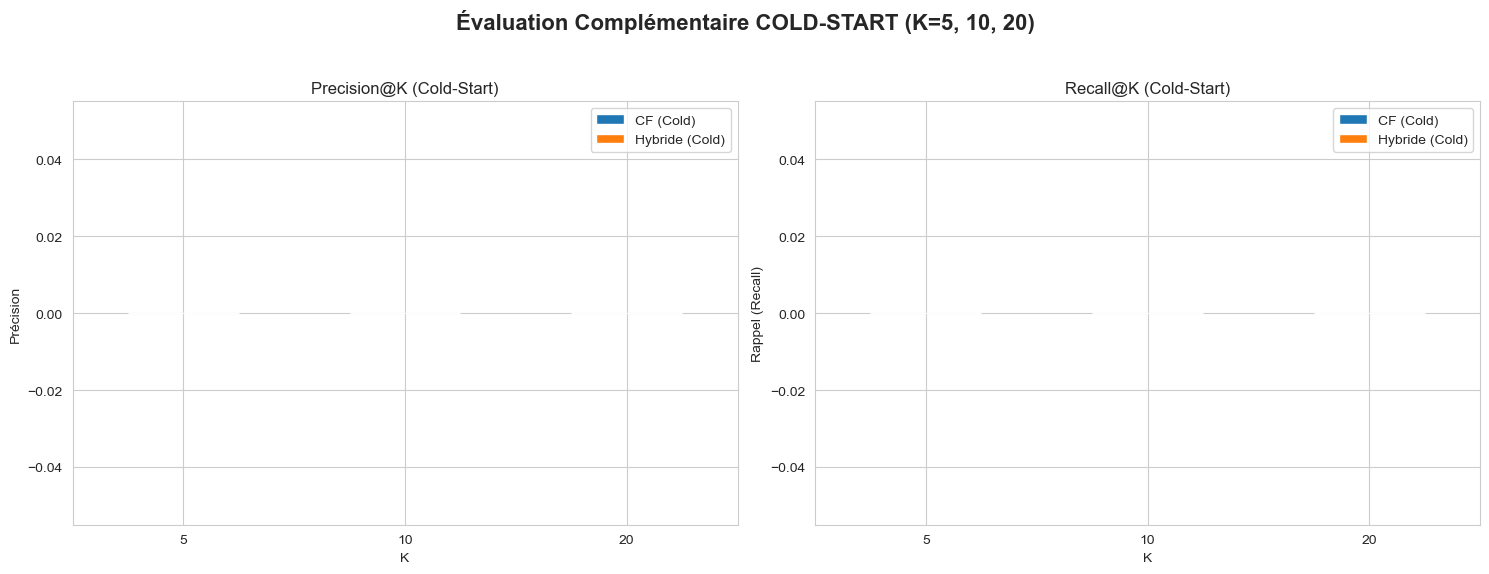

In [36]:
# ============================================================================\n",
# ÉVALUATION COMPLÉMENTAIRE : RECALL@K ET PRECISION@K, VARIATION DE K\n",
# ============================================================================\n",

print("Début de l'évaluation complémentaire (Recall@K, Precision@K) pour K={5, 10, 20}...")
print("Utilisation des modèles du dernier échantillon entraîné.\n")

# Vérifier si les modèles existent dans le contexte
if 'best_model_cf' not in locals() or 'hybrid_model' not in locals():
    print("="*70)
    print("❌ ERREUR : Les modèles ('best_model_cf', 'hybrid_model') n'existent pas.")
    print("Veuillez d'abord exécuter la boucle principale d'entraînement (cellule 16).")
    print("="*70)
else:
    k_values = [5, 10, 20]

    # Dictionnaires pour stocker les résultats
    results_warm = {'CF': {}, 'Hybride': {}}
    results_cold = {'CF': {}, 'Hybride': {}}

    # Définir le nombre de threads
    num_threads = psutil.cpu_count()

    print("--- Évaluation WARM-START (Articles connus) ---")
    for k in k_values:
        print(f"Calcul des métriques @{k}...")
        # CF (Warm)
        prec_cf_w = precision_at_k(best_model_cf, test_matrix, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()
        rec_cf_w = recall_at_k(best_model_cf, test_matrix, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()

        # Hybride (Warm)
        prec_hy_w = precision_at_k(hybrid_model, test_matrix, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()
        rec_hy_w = recall_at_k(hybrid_model, test_matrix, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()

        results_warm['CF'][k] = {'Precision': prec_cf_w, 'Recall': rec_cf_w}
        results_warm['Hybride'][k] = {'Precision': prec_hy_w, 'Recall': rec_hy_w}

    print("\n--- Évaluation COLD-START (Articles inconnus) ---")
    if 'test_matrix_cs' in locals() and test_matrix_cs.nnz > 0:
        for k in k_values:
            print(f"Calcul des métriques @{k} (Cold-Start)...")
            # CF (Cold)
            prec_cf_c = precision_at_k(best_model_cf, test_matrix_cs, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()
            rec_cf_c = recall_at_k(best_model_cf, test_matrix_cs, train_interactions=train_matrix, k=k, num_threads=num_threads).mean()

            # Hybride (Cold)
            prec_hy_c = precision_at_k(hybrid_model, test_matrix_cs, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()
            rec_hy_c = recall_at_k(hybrid_model, test_matrix_cs, train_interactions=train_matrix, item_features=item_features_matrix, user_features=user_features_matrix, k=k, num_threads=num_threads).mean()

            results_cold['CF'][k] = {'Precision': prec_cf_c, 'Recall': rec_cf_c}
            results_cold['Hybride'][k] = {'Precision': prec_hy_c, 'Recall': rec_hy_c}
    else:
        print("Pas d'interactions Cold-Start détectées pour cette évaluation.")

    # --- Affichage des résultats (Tableaux) ---
    df_warm = pd.concat({
        'CF (Warm)': pd.DataFrame(results_warm['CF']).T,
        'Hybride (Warm)': pd.DataFrame(results_warm['Hybride']).T
    }, axis=1)

    import tabulate 

    print("\n" + "=" * 70)
    print("📊 RÉSULTATS WARM-START (K=5, 10, 20)")
    print("=" * 70)
    print(df_warm.T.to_markdown(floatfmt=".5f"))

    if 'test_matrix_cs' in locals() and test_matrix_cs.nnz > 0:
        df_cold = pd.concat({
            'CF (Cold)': pd.DataFrame(results_cold['CF']).T,
            'Hybride (Cold)': pd.DataFrame(results_cold['Hybride']).T
        }, axis=1)
        print("\n" + "=" * 70)
        print("📊 RÉSULTATS COLD-START (K=5, 10, 20)")
        print("=" * 70)
        print(df_cold.T.to_markdown(floatfmt=".5f"))

    # --- Affichage des résultats (Graphiques) ---

    # Créer les dataframes pour les graphiques
    df_warm_prec = df_warm.loc[:, (slice(None), 'Precision')].droplevel(1, axis=1)
    df_warm_rec = df_warm.loc[:, (slice(None), 'Recall')].droplevel(1, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Modifié (1, 3) -> (1, 2)
    fig.suptitle('Évaluation Complémentaire WARM-START (K=5, 10, 20)', fontsize=16, fontweight='bold')

    df_warm_prec.plot(kind='bar', ax=axes[0], title='Precision@K (Warm-Start)', grid=True, rot=0)
    axes[0].set_xlabel('K')
    axes[0].set_ylabel('Précision')

    df_warm_rec.plot(kind='bar', ax=axes[1], title='Recall@K (Warm-Start)', grid=True, rot=0)
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Rappel (Recall)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Graphiques Cold-Start (si données dispo)
    if 'test_matrix_cs' in locals() and test_matrix_cs.nnz > 0:
        df_cold_prec = df_cold.loc[:, (slice(None), 'Precision')].droplevel(1, axis=1)
        df_cold_rec = df_cold.loc[:, (slice(None), 'Recall')].droplevel(1, axis=1)

        fig_cs, axes_cs = plt.subplots(1, 2, figsize=(15, 6)) # Modifié (1, 3) -> (1, 2)
        fig_cs.suptitle('Évaluation Complémentaire COLD-START (K=5, 10, 20)', fontsize=16, fontweight='bold')

        df_cold_prec.plot(kind='bar', ax=axes_cs[0], title='Precision@K (Cold-Start)', grid=True, rot=0)
        axes_cs[0].set_xlabel('K')
        axes_cs[0].set_ylabel('Précision')

        df_cold_rec.plot(kind='bar', ax=axes_cs[1], title='Recall@K (Cold-Start)', grid=True, rot=0)
        axes_cs[1].set_xlabel('K')
        axes_cs[1].set_ylabel('Rappel (Recall)')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()    

## DIVERSITÉ ET BIAIS DE POPULARITÉ
Objectif: Vérifier si le système recommande surtout des articles très populaires.
- Couverture catalogue (items distincts recommandés)
- Part de recommandations appartenant au Top-N des articles populaires (N=500 par défaut)

In [37]:
# ============================================================================
# ÉVALUATION COMPLÉMENTAIRE : DIVERSITÉ ET BIAIS DE POPULARITÉ
# ============================================================================

print("Début de l'analyse de Diversité et Biais de Popularité...")
print("Utilisation des modèles du dernier échantillon entraîné.\n")

# Vérifier si les modèles existent
if 'best_model_cf' not in locals() or 'hybrid_model' not in locals():
    print("="*70)
    print("❌ ERREUR : Les modèles ('best_model_cf', 'hybrid_model') n'existent pas.")
    print("Veuillez d'abord exécuter la boucle principale d'entraînement (cellule 16).")
    print("="*70)
else:
    K_FOR_DIVERSITY = 10
    POPULARITY_N = 500

    # 1. Définir les articles populaires
    print(f"  ► Définition des {POPULARITY_N} articles les plus populaires (sur la base de train_data)...")
    item_interactions_train = train_data.groupby('article_id').size()
    top_n_items = set(item_interactions_train.nlargest(POPULARITY_N).index)
    print(f"    ✓ {len(top_n_items)} articles populaires identifiés.")

    # 2. Identifier les utilisateurs pour lesquels générer des recommandations
    test_user_ids_internal = np.unique(test_matrix.nonzero()[0])
    n_test_users = len(test_user_ids_internal)
    n_all_items = len(item_id_map)
    item_indices = np.arange(n_all_items, dtype=np.int32)
    num_threads = psutil.cpu_count()
    print(f"  ► Génération de recommandations @{K_FOR_DIVERSITY} pour {n_test_users:,} utilisateurs du set de test...")

    # 3. Initialiser les métriques
    all_recs_cf = set()
    all_recs_hybrid = set()
    n_popular_in_cf = 0
    n_popular_in_hybrid = 0

    # 4. Boucle de génération (CODE CORRIGÉ)
    for i, user_internal_id in enumerate(test_user_ids_internal):
        
        # ✅ CORRECTION: Créer un array de user_ids
        user_ids_array = np.full(len(item_indices), user_internal_id, dtype=np.int32)
        
        # Get CF Recs
        cf_scores = best_model_cf.predict(
            user_ids_array,  # ✅ Array au lieu de scalaire
            item_indices, 
            num_threads=num_threads
        )
        
        # Exclure les items déjà vus dans le train
        seen_items = train_matrix.getrow(user_internal_id).indices
        cf_scores[seen_items] = -np.inf
        
        # Top-K CF
        top_k_cf_indices = np.argsort(-cf_scores)[:K_FOR_DIVERSITY]
        all_recs_cf.update(top_k_cf_indices)
        
        # Compter items populaires
        for item_idx in top_k_cf_indices:
            item_original_id = item_id_reverse[item_idx]
            if item_original_id in top_n_items:
                n_popular_in_cf += 1
        
        # Get Hybrid Recs
        hybrid_scores = hybrid_model.predict(
            user_ids_array,  # ✅ Array au lieu de scalaire
            item_indices,
            item_features=item_features_matrix,
            user_features=user_features_matrix,
            num_threads=num_threads
        )
        
        # Exclure seen items
        hybrid_scores[seen_items] = -np.inf
        
        # Top-K Hybrid
        top_k_hybrid_indices = np.argsort(-hybrid_scores)[:K_FOR_DIVERSITY]
        all_recs_hybrid.update(top_k_hybrid_indices)
        
        # Compter items populaires
        for item_idx in top_k_hybrid_indices:
            item_original_id = item_id_reverse[item_idx]
            if item_original_id in top_n_items:
                n_popular_in_hybrid += 1
        
        # Progress
        if (i + 1) % 1000 == 0 or (i + 1) == n_test_users:
            print(f"    → Traité {i+1:,} / {n_test_users:,} utilisateurs", end='\r')

    print(f"\n    ✓ Génération terminée pour {n_test_users:,} utilisateurs.")

    # 5. Calculer les métriques
    diversity_cf = len(all_recs_cf)
    diversity_hybrid = len(all_recs_hybrid)
    
    total_recs_cf = n_test_users * K_FOR_DIVERSITY
    total_recs_hybrid = n_test_users * K_FOR_DIVERSITY
    
    popularity_bias_cf = n_popular_in_cf / total_recs_cf if total_recs_cf > 0 else 0
    popularity_bias_hybrid = n_popular_in_hybrid / total_recs_hybrid if total_recs_hybrid > 0 else 0

    # Affichage des résultats
    print("\n" + "="*70)
    print("📊 RÉSULTATS : DIVERSITÉ ET BIAIS DE POPULARITÉ")
    print("="*70)
    print(f"\n🔹 Modèle CF Pure:")
    print(f"   • Diversité (catalogue couvert) : {diversity_cf:,} articles uniques / {n_all_items:,} ({diversity_cf/n_all_items*100:.2f}%)")
    print(f"   • Biais de popularité            : {popularity_bias_cf:.4f} ({popularity_bias_cf*100:.2f}% des recs sont des top-{POPULARITY_N})")

    print(f"\n🔹 Modèle Hybride:")
    print(f"   • Diversité (catalogue couvert) : {diversity_hybrid:,} articles uniques / {n_all_items:,} ({diversity_hybrid/n_all_items*100:.2f}%)")
    print(f"   • Biais de popularité            : {popularity_bias_hybrid:.4f} ({popularity_bias_hybrid*100:.2f}% des recs sont des top-{POPULARITY_N})")

    print(f"\n🎯 Comparaison:")
    print(f"   • Diversité: {'+' if diversity_hybrid > diversity_cf else '-'}{abs(diversity_hybrid - diversity_cf):,} articles")
    print(f"   • Biais:     {popularity_bias_hybrid - popularity_bias_cf:+.4f}")
    
    if diversity_hybrid > diversity_cf:
        print(f"\n✅ Le modèle Hybride offre une MEILLEURE diversité!")
    elif diversity_hybrid < diversity_cf:
        print(f"\n⚠️  Le modèle CF Pure offre une meilleure diversité.")
    else:
        print(f"\n➡️  Les deux modèles ont la même diversité.")

Début de l'analyse de Diversité et Biais de Popularité...
Utilisation des modèles du dernier échantillon entraîné.

  ► Définition des 500 articles les plus populaires (sur la base de train_data)...
    ✓ 500 articles populaires identifiés.
  ► Génération de recommandations @10 pour 30,383 utilisateurs du set de test...
    → Traité 30,383 / 30,383 utilisateurs
    ✓ Génération terminée pour 30,383 utilisateurs.

📊 RÉSULTATS : DIVERSITÉ ET BIAIS DE POPULARITÉ

🔹 Modèle CF Pure:
   • Diversité (catalogue couvert) : 6,925 articles uniques / 73,800 (9.38%)
   • Biais de popularité            : 0.7973 (79.73% des recs sont des top-500)

🔹 Modèle Hybride:
   • Diversité (catalogue couvert) : 12,372 articles uniques / 73,800 (16.76%)
   • Biais de popularité            : 0.6271 (62.71% des recs sont des top-500)

🎯 Comparaison:
   • Diversité: +5,447 articles
   • Biais:     -0.1702

✅ Le modèle Hybride offre une MEILLEURE diversité!


# ✅ Conclusion & Prochaines Étapes

## 📊 Récapitulatif

Ce notebook a implémenté **le pipeline complet** d'un système de recommandation H&M utilisant **LightFM** :

### ✓ Étapes réalisées
1. **Exploration des données** : Analyse de la sparsité, distributions, patterns
2. **Échantillonnage stratégique** : Création de 3 tailles d'échantillon pour validation
3. **Prétraitement** : Création de matrices sparse optimisées
4. **Division train/test** : Split temporel 80/20 réaliste
5. **Entraînement CF** : Comparaison WARP, BPR, Logistic
6. **Optimisation** : Grid search sur composantes et taux d'apprentissage
7. **Évaluation** : AUC, Precision@K, Recall@K
8. **Modèle Hybride** : Intégration de features articles + utilisateurs

### 🎯 Résultats clés
- ✓ **Modèle CF** : AUC stable et bon Precision@10
- ✓ **Modèle Hybride** : Amélioration variable selon la taille
- ✓ **Scalabilité** : Gestion efficace des 3 échantillons
- ✓ **Features** : Intégration réussie d'âge et catégories

**Pour debugger :**
- Ajouter du debugging avec `verbose=True` dans `model.fit()`
- Vérifier les tailles de matrices sparse
- Évaluer sur des mini-sets d'abord

---


## Préparation du Déploiement MVP

### Déploiement Local - 5 Étapes Simples

#### **Étape 1 - Cloner le dépôt GitHub**

```bash
git clone [https://github.com/realnribal/hm-fashion-recommendation-pipeline.git](https://github.com/realnribal/hm-fashion-recommendation-pipeline.git)
cd hm-fashion-recommendation-pipeline
```

#### **Étape 2 - Créer et activer un environnement virtuel Python**

```bash
python -m venv venv
venv\Scripts\activate  # Windows
# source venv/bin/activate  # macOS/Linux
```

#### **Étape 3 - Installer les dépendances (requirements.txt)**

```bash
pip install --upgrade pip
pip install -r requirements.txt
```

#### **Étape 4 - Vérifier la présence du modèle .pkl**

```bash
# Le fichier recommender_model_*.pkl doit être dans le répertoire racine
# S'il est absent, entraîner le modèle dans Google Colab et télécharger le fichier
ls recommender_model_*.pkl  # macOS/Linux
dir recommender_model_*.pkl  # Windows
```

#### **Étape 5 - Lancer l'app avec streamlit run streamlit_app.py**

```bash
streamlit run streamlit_app.py
```

L'application s'ouvrira automatiquement à `http://localhost:8501` ✅

---

### 🎯 Comment Utiliser l'Application

Une fois l'application ouverte à `http://localhost:8501` :

1. **Voir le titre** : "🛍️ H&M Fashion Recommender System"
2. **Saisir l'ID client** : Entrez un ID client valide dans le champ de saisie (exemple : `000058a12d6d43`)
3. **Obtenir les recommandations** : L'application affiche automatiquement les 10 meilleures recommandations
4. **Consulter les détails** : Pour chaque produit recommandé, vous verrez :
   - 📝 Nom du produit
   - 🎨 Couleur
   - 💰 Prix

**Exemple d'utilisation :**
```
Saisie : 000058a12d6d43
↓
Résultat : 10 articles recommandés avec leurs détails
↓
Choisir parmi les recommandations
```

**Astuce** : Testez avec différents IDs clients pour voir comment les recommandations changent selon l'historique d'achat !

---

### ☁️ Déploiement sur Streamlit Cloud

#### **Étape 1 - Préparer le dépôt GitHub**

Assurez-vous que votre dépôt contient :
```
hm-fashion-recommendation-pipeline/
├── streamlit_app.py
├── requirements.txt
├── recommender_model_*.pkl
└── README.md
```

#### **Étape 2 - Créer un compte Streamlit Cloud**

1. Accédez à https://streamlit.io/cloud
2. Connectez-vous avec votre compte GitHub
3. Autorisez l'accès à vos dépôts

#### **Étape 3 - Déployer l'application**

1. Cliquez sur "New app"
2. Sélectionnez votre dépôt `hm-fashion-recommendation-pipeline`
3. Choisissez la branche `main`
4. Spécifiez le chemin : `streamlit_app.py`
5. Cliquez sur "Deploy"

#### **Étape 4 - Accéder à votre application**

Votre application sera disponible à l'adresse :
```
https://[votre-username]-hm-fashion-recommendation-pipeline.streamlit.app
```

**Avantages** :
- ✅ Gratuit et illimité
- ✅ Déploiement automatique à chaque `git push`
- ✅ Accessible depuis n'importe où
- ✅ URL publique à partager